In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

In [27]:
# Data loading
day_df = pd.read_csv('/Users/nienkeposthumus/Documents/AI year 3/Applied ML/dates_with_weekdays.csv')
visitors_df = pd.read_csv('/Users/nienkeposthumus/Documents/AI year 3/Applied ML/WEEVA_GUESTS.csv')

weather1_df = pd.read_csv('/Users/nienkeposthumus/Documents/AI year 3/Applied ML/Groningen 2018-11-01 to 2021-05-31.csv')
weather2_df = pd.read_csv('/Users/nienkeposthumus/Documents/AI year 3/Applied ML/Groningen 2021-06-01 to 2023-12-31.csv')
weather3_df = pd.read_csv('/Users/nienkeposthumus/Documents/AI year 3/Applied ML/Groningen 2024-01-01 to 2025-04-28.csv')

weather_df = pd.concat([weather1_df, weather2_df, weather3_df], ignore_index=True)

restaurant_df = visitors_df.join(day_df)

# restaurant_df = pd.read_csv('/Users/nienkeposthumus/Documents/AI year 3/Applied ML/full_df.csv')

In [28]:
# First analysis of the data and its columns

restaurant_df = restaurant_df[["Date", "GUESTS", "DayOfWeek", "IsWeekend"]]
restaurant_df = restaurant_df.rename(columns={"GUESTS":"Guests"})
restaurant_df = restaurant_df.join(weather_df)
restaurant_df.head(5)

,Date,Guests,DayOfWeek,IsWeekend,name,datetime,tempmax,tempmin,temp,feelslikemax,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,2018-11-01,0,Thursday,False,Groningen,2018-11-01,12.9,7.2,9.5,12.9,...,2.3,1,NaN,2018-11-01T07:31:39,2018-11-01T17:02:05,0.78,"Rain, Partially cloudy",Partly cloudy throughout the day with rain.,rain,"06279099999,E0051,05839,06286099999,07373,0628..."
1,2018-11-02,0,Friday,False,Groningen,2018-11-02,11.0,1.7,8.2,11.0,...,2.2,1,NaN,2018-11-02T07:33:33,2018-11-02T17:00:09,0.81,"Rain, Partially cloudy",Partly cloudy throughout the day with a chance...,rain,"06279099999,06270099999,E0051,05839,0628609999..."
2,2018-11-03,0,Saturday,True,Groningen,2018-11-03,10.0,0.6,4.6,10.0,...,1.7,1,NaN,2018-11-03T07:35:26,2018-11-03T16:58:15,0.85,Clear,Clear conditions throughout the day.,clear-day,"06279099999,06270099999,E0051,05839,0628609999..."
3,2018-11-04,0,Sunday,True,Groningen,2018-11-04,10.7,-0.4,5.2,10.7,...,2.0,1,NaN,2018-11-04T07:37:20,2018-11-04T16:56:23,0.89,Partially cloudy,Becoming cloudy in the afternoon.,partly-cloudy-day,"06279099999,06270099999,E0051,05839,0628609999..."
4,2018-11-05,108,Monday,False,Groningen,2018-11-05,10.1,5.9,8.8,10.1,...,1.1,1,NaN,2018-11-05T07:39:14,2018-11-05T16:54:33,0.92,Overcast,Cloudy skies throughout the day.,cloudy,"06279099999,06270099999,E0051,05839,0628609999..."


In [16]:
restaurant_df.dtypes
weather_df.shape

(2371, 33)

In [17]:
restaurant_df["DayOfWeek"] = restaurant_df["DayOfWeek"].astype("string")
restaurant_df["Date"] = pd.to_datetime(restaurant_df["Date"])
restaurant_df["Guests"] = restaurant_df["Guests"].str.replace(",", "")
restaurant_df["Guests"] = restaurant_df["Guests"].astype(int)

In [18]:
restaurant_df.isna().sum()

Date                   0
Guests                 0
DayOfWeek              0
IsWeekend              0
name                   0
datetime               0
tempmax                0
tempmin                0
temp                   0
feelslikemax           0
feelslikemin           0
feelslike              0
dew                    0
humidity               0
precip                 0
precipprob             0
precipcover            0
preciptype           671
snow                   0
snowdepth              0
windgust               0
windspeed              0
winddir                0
sealevelpressure       0
cloudcover             0
visibility             0
solarradiation         0
solarenergy            0
uvindex                0
severerisk          2371
sunrise                0
sunset                 0
moonphase              0
conditions             0
description            0
icon                   0
stations               0
dtype: int64

<Axes: xlabel='Weekend', ylabel='Mean number of guests'>

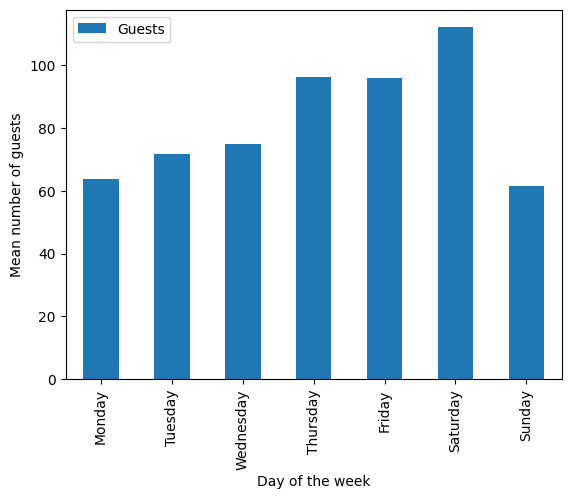

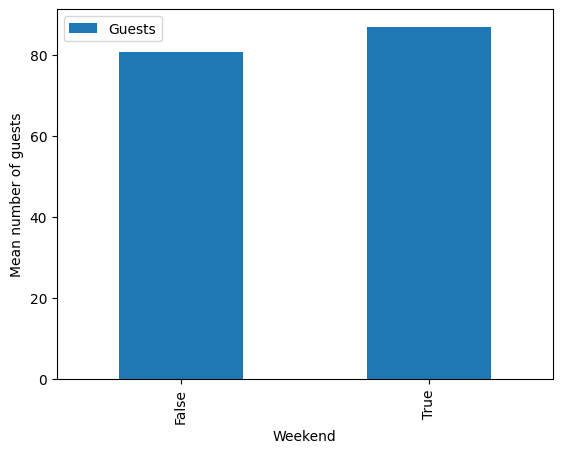

In [19]:
day_of_week_feature = restaurant_df[["DayOfWeek", "Guests"]].groupby("DayOfWeek").mean()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_of_week_feature = day_of_week_feature.reindex(day_order)
day_of_week_feature.plot(kind="bar", xlabel = "Day of the week", ylabel="Mean number of guests")

weekend_feature = restaurant_df[["IsWeekend", "Guests"]].groupby("IsWeekend").mean()
weekend_feature.plot(kind="bar", xlabel = "Weekend", ylabel="Mean number of guests")


0.004892627076877535


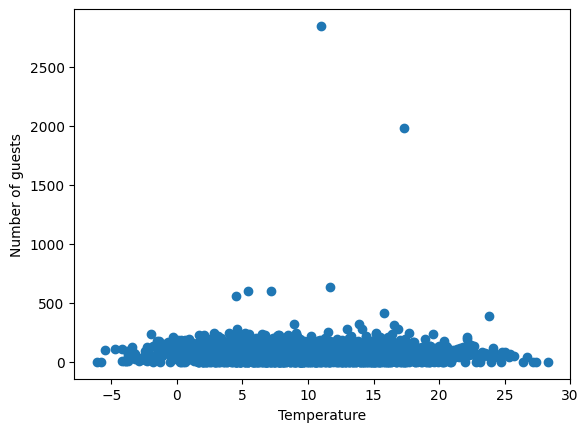

In [20]:
plt.scatter(restaurant_df["temp"], restaurant_df["Guests"])
plt.xlabel("Temperature")
plt.ylabel("Number of guests")
print(restaurant_df["temp"].corr(restaurant_df["Guests"]))

Text(0, 0.5, 'Density')

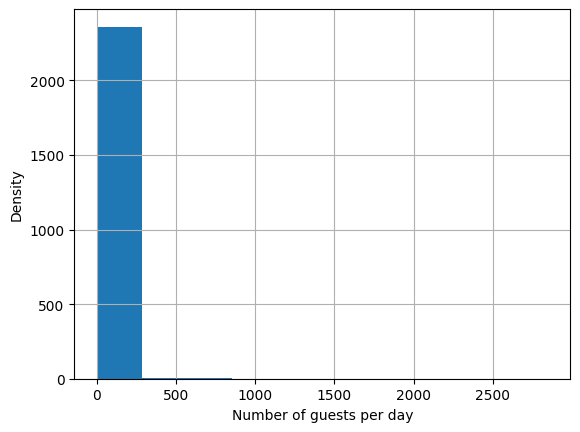

In [10]:
restaurant_df["Guests"].hist()
plt.xlabel("Number of guests per day")
plt.ylabel("Density")

In [194]:
non_numberic = ["Date", "DayOfWeek", "IsWeekend", "name", "datetime", "severerisk", "sunrise", "sunset", "conditions", "description", "icon", "stations", "preciptype"]
numeric_restaurant_df = restaurant_df.drop(non_numberic, axis=1)

numeric_restaurant_df.head(5)

,Guests,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,...,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,moonphase
0,0,12.9,7.2,9.5,12.9,4.6,8.0,6.7,83.5,2.532,...,35.0,16.3,135.9,1009.5,21.5,10.7,26.3,2.3,1,0.78
1,0,11.0,1.7,8.2,11.0,-1.1,6.7,5.8,85.6,1.095,...,49.4,22.5,234.3,1017.9,40.6,10.5,25.8,2.2,1,0.81
2,0,10.0,0.6,4.6,10.0,-1.9,2.7,2.8,89.2,0.000,...,30.9,15.5,178.5,1027.0,6.1,8.1,20.3,1.7,1,0.85
3,0,10.7,-0.4,5.2,10.7,-2.5,3.4,3.8,91.3,0.000,...,25.7,13.7,119.7,1017.1,25.9,5.6,24.8,2.0,1,0.89
4,108,10.1,5.9,8.8,10.1,4.3,7.9,7.8,93.7,0.000,...,30.9,15.4,96.0,1009.7,97.1,3.9,13.8,1.1,1,0.92


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: 

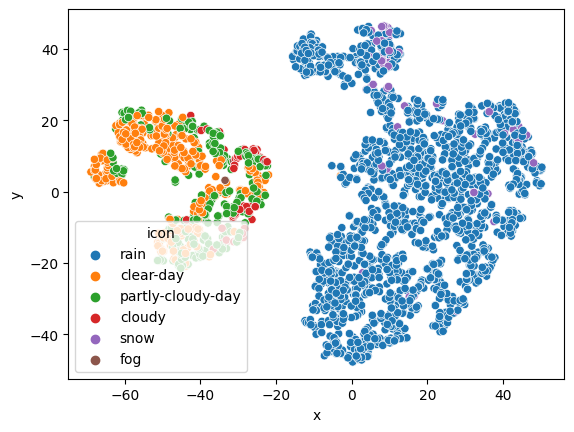

In [206]:
model = TSNE(learning_rate=50)
tsne_features = model.fit_transform(numeric_restaurant_df)
tsne_features[1:4, :]
restaurant_df['x'] = tsne_features[:, 0]
restaurant_df['y'] = tsne_features[:, 1]

sns.scatterplot(x="x", y="y", hue="icon", data=restaurant_df)
plt.show()


In [11]:
restaurant_df.to_csv("restaurant_dataframe.csv")

In [26]:
filtered_restaurant_df = restaurant_df[restaurant_df["Guests"] != 0]

print((filtered_restaurant_df["Guests"] == 0).sum())

filtered_restaurant_df.shape

0


(2124, 37)

In [8]:
menu18_22_df = pd.read_csv('/Users/nienkeposthumus/Documents/AI year 3/Applied ML/Weeva_data_2018-2022.csv')
menu23_25_df = pd.read_csv('/Users/nienkeposthumus/Documents/AI year 3/Applied ML/Weeva_Data_2023-x.csv')

menu_df = pd.concat([menu18_22_df, menu23_25_df], ignore_index=True)
menu_df.head(20)

,Date,Article,Sold articles amount
0,27-11-2018,Heineken 25cl,31
1,27-11-2018,Chardonnay Glas,4
2,27-11-2018,3 Gang Arrangement,1
3,27-11-2018,Heineken 22cl,2
4,27-11-2018,Schnitzel,8
5,27-11-2018,Sourcy Blauw 20cl,3
6,27-11-2018,Kalmoes Beerenburg,1
7,27-11-2018,Espresso,3
8,27-11-2018,Sauvignon Blanc Glas,14
9,27-11-2018,Stamppot vd dag,3


In [10]:
pivoted_menu_df = menu_df.pivot_table(index="Date", columns='Article', values='Sold articles amount', fill_value=0)
pivoted_menu_df.head(20)

Article,1 Gang Arrangement,1 kroket brood,12 Uurtje,2 Gang Arrangement,2 Kroketten Frites,2 kroketten Brood,3 Gang Arrangement,3 flesjes bier to go,3 flesjes desperados to go,3 gangen wijn,...,Zuurkool TB,Zweigelt - Huber,"Zweigelt, Huber",advertentiekosten APIH,"extra hapjes 1,30",geluidset huur,ijscowagen huur,kalkoenfilet - kids kerst,materialen en transport,materialen huur
Sold articles amount,30.0,1.0,2.619718,3.333333,1.480769,1.887324,3.777778,1.666667,1.0,5.5,...,1.526316,1.0,1.0,2.0,52.0,1.0,1.0,5.75,1.333333,9.75


In [39]:
full_restaurant_df = pd.read_csv('/Users/nienkeposthumus/Documents/AI year 3/Applied ML/restaurant_dataframe.csv')
full_restaurant_df.shape


full_restaurant_df = full_restaurant_df.drop(["name", "datetime", "stations", "severerisk"], axis=1)
full_restaurant_df.head(10)

,Unnamed: 0,Date,Guests,DayOfWeek,IsWeekend,tempmax,tempmin,temp,feelslikemax,feelslikemin,...,visibility,solarradiation,solarenergy,uvindex,sunrise,sunset,moonphase,conditions,description,icon
0,0,2018-11-01,0,Thursday,False,12.9,7.2,9.5,12.9,4.6,...,10.7,26.3,2.3,1,2018-11-01T07:31:39,2018-11-01T17:02:05,0.78,"Rain, Partially cloudy",Partly cloudy throughout the day with rain.,rain
1,1,2018-11-02,0,Friday,False,11.0,1.7,8.2,11.0,-1.1,...,10.5,25.8,2.2,1,2018-11-02T07:33:33,2018-11-02T17:00:09,0.81,"Rain, Partially cloudy",Partly cloudy throughout the day with a chance...,rain
2,2,2018-11-03,0,Saturday,True,10.0,0.6,4.6,10.0,-1.9,...,8.1,20.3,1.7,1,2018-11-03T07:35:26,2018-11-03T16:58:15,0.85,Clear,Clear conditions throughout the day.,clear-day
3,3,2018-11-04,0,Sunday,True,10.7,-0.4,5.2,10.7,-2.5,...,5.6,24.8,2.0,1,2018-11-04T07:37:20,2018-11-04T16:56:23,0.89,Partially cloudy,Becoming cloudy in the afternoon.,partly-cloudy-day
4,4,2018-11-05,108,Monday,False,10.1,5.9,8.8,10.1,4.3,...,3.9,13.8,1.1,1,2018-11-05T07:39:14,2018-11-05T16:54:33,0.92,Overcast,Cloudy skies throughout the day.,cloudy
5,5,2018-11-06,99,Tuesday,False,16.6,6.4,10.8,16.6,5.3,...,6.7,21.6,1.7,1,2018-11-06T07:41:07,2018-11-06T16:52:44,0.96,Partially cloudy,Clearing in the afternoon.,partly-cloudy-day
6,6,2018-11-07,102,Wednesday,False,15.0,9.0,11.5,15.0,6.9,...,10.6,22.3,1.9,1,2018-11-07T07:43:01,2018-11-07T16:50:58,0.00,Clear,Clear conditions throughout the day.,clear-day
7,7,2018-11-08,96,Thursday,False,13.0,2.6,9.1,13.0,1.1,...,11.0,19.8,1.8,1,2018-11-08T07:44:54,2018-11-08T16:49:13,0.03,Clear,Clear conditions throughout the day.,clear-day
8,8,2018-11-09,172,Friday,False,11.8,3.3,7.9,11.8,1.2,...,7.8,17.2,1.3,1,2018-11-09T07:46:47,2018-11-09T16:47:30,0.06,"Rain, Partially cloudy",Partly cloudy throughout the day with rain in ...,rain
9,9,2018-11-10,257,Saturday,True,13.0,8.9,11.5,13.0,6.7,...,10.7,10.2,0.9,1,2018-11-10T07:48:40,2018-11-10T16:45:49,0.09,"Rain, Partially cloudy",Partly cloudy throughout the day with rain.,rain


In [44]:
date_ranges = [
    ('2020-03-01', '2020-05-31'),
    ('2020-12-01', '2021-06-30'),
    ('2021-11-01', '2022-01-31')
]

for start_date, end_date in date_ranges:
    full_restaurant_df = full_restaurant_df[
        ~((full_restaurant_df['Date'] >= start_date) & (full_restaurant_df['Date'] <= end_date))
    ]

print(full_restaurant_df.shape)

(1975, 34)


In [45]:
full_restaurant_df.to_csv("full_restaurant_without_covid_df.csv")